# Proyek Analisis Data: Brazilian E-Commerce Public Dataset by Olist
- **Nama:** Alissya Humairah Martiasaputri
- **Email:** alissyahumairah@gmail.com
- **ID Dicoding:** 	CDCC319D6X2692

## Menentukan Pertanyaan Bisnis

- Berapa rata-rata keterlambatan pengiriman per negara bagian di Brazil?
- Kategori produk apa yang paling banyak mendapat review bintang 1-2?
- Metode pembayaran apa yang paling sering digunakan pelanggan Olist?

Menggunakan RFM analysis:
- Siapa saja pelanggan paling bernilai di Olist berdasarkan seberapa sering dan seberapa besar mereka bertransaksi?
- Berapa persentase pelanggan Olist yang sudah lama tidak melakukan transaksi kembali?
- Di kota atau negara bagian mana pelanggan paling bernilai di Olist paling banyak tersebar?

alasan memberikan pertanyaan ini:
- Pertanyaan 1: Bagaimana performa delivery?
Karena kalau barang lama sampai atau sering terlambat, customer bisa kecewa. Jadi ini untuk cek apakah operasional logistik sudah bagus atau belum.

- Pertanyaan 2: Produk apa yang bermasalah?
Kalau banyak review jelek, berarti ada masalah di kualitas produk atau ekspektasi customer. Ini supaya perusahaan tahu produk mana yang perlu diperbaiki atau dievaluasi.

- Pertanyaan 3: Bagaimana perilaku pembayaran customer?
Supaya perusahaan tahu kebiasaan customer saat belanja.

- Pertanyaan 4: Siapa customer paling valuable?
Karena biasanya sebagian kecil customer menghasilkan sebagian besar revenue. Jadi perusahaan harus tahu siapa yang harus dijaga loyalitasnya.

- Pertanyaan 5: Apakah ada customer yang berisiko hilang?
Lebih mudah mempertahankan customer lama daripada cari customer baru. Jadi penting tahu siapa yang sudah lama tidak belanja supaya bisa ditarget promo.

- Pertanyaan 6: Dimana customer terbaik berada?
Supaya perusahaan tahu daerah mana yang potensial untuk marketing atau ekspansi bisnis.

## Import Semua Packages/Library yang Digunakan

In [318]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [319]:
sellers_df = pd.read_csv("https://raw.githubusercontent.com/alissyaa/olist-data-analysis/refs/heads/main/dataset/olist_sellers_dataset.csv")
sellers_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


**Insight:**
- Memuat data sellers
- Menampilkan 5 baris pertama dari DataFrame sellers_df

In [320]:
products_df = pd.read_csv("https://raw.githubusercontent.com/alissyaa/olist-data-analysis/refs/heads/main/dataset/olist_products_dataset.csv")
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


**Insight:**
- Memuat data products
- Menampilkan 5 baris pertama dari DataFrame products_df

In [321]:
reviews_df = pd.read_csv("https://raw.githubusercontent.com/alissyaa/olist-data-analysis/refs/heads/main/dataset/olist_order_reviews_dataset.csv")
reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


**Insight:**
- Memuat data reviews
- Menampilkan 5 baris pertama dari DataFrame reviews_df

In [322]:
orders_df = pd.read_csv("https://raw.githubusercontent.com/alissyaa/olist-data-analysis/refs/heads/main/dataset/olist_orders_dataset.csv")
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


**Insight:**
- Memuat data orders
- Menampilkan 5 baris pertama dari DataFrame orders_df

In [323]:
payments_df = pd.read_csv("https://raw.githubusercontent.com/alissyaa/olist-data-analysis/refs/heads/main/dataset/olist_order_payments_dataset.csv")
payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


**Insight:**
- Memuat data payments
- Menampilkan 5 baris pertama dari DataFrame payments_df

In [324]:
items_df = pd.read_csv("https://raw.githubusercontent.com/alissyaa/olist-data-analysis/refs/heads/main/dataset/olist_order_items_dataset.csv")
items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


**Insight:**
- Memuat data items
- Menampilkan 5 baris pertama dari DataFrame items_df

In [325]:
geolocation_df = pd.read_csv("https://raw.githubusercontent.com/alissyaa/olist-data-analysis/refs/heads/main/dataset/olist_geolocation_dataset.csv")
geolocation_df.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


**Insight:**
- Memuat data geolocation
- Menampilkan 5 baris pertama dari DataFrame geolocation_df

In [326]:
customers_df = pd.read_csv("https://raw.githubusercontent.com/alissyaa/olist-data-analysis/refs/heads/main/dataset/olist_customers_dataset.csv")
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


**Insight:**
- Memuat data customers
- Menampilkan 5 baris pertama dari DataFrame customers_df

**Insight:**
- Total ada 8 tabel yang di muat, yaitu:
- sellers_df
- products_df
- reviews_df
- orders_df
- payments_df
- items_df
- geolocation_df
- customers_df

note: disini saya load semua dataset dari sumber dan totalnya ada 8 dataset

### Assessing Data

In [327]:
sellers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


**Insight:**
- kode ini untuk memberikan informasi rincian dari tabel sellers
- di tabel ini tidak ada missing value, semuanya sama, jadi tidak perlu dicek berapa nan nya
- Untuk tipe data juga pas tidak ada yang berbeda atau sudah sesuai

In [328]:
print("Jumlah duplikasi: ",sellers_df.duplicated().sum())
sellers_df.describe()

Jumlah duplikasi:  0


,seller_zip_code_prefix
count,3095.000000
mean,32291.059451
std,32713.453830
min,1001.000000
25%,7093.500000
50%,14940.000000
75%,64552.500000
max,99730.000000


**Insight:**
- tidak ada data yang duplikasi
- untuk nilai juga sudah sesuai, tidak ada yang inaccurate value

In [329]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


**Insight:**
- kode ini untuk memberikan informasi rincian dari tabel products
- di tabel ini terdapat missing value di beberapa kolom kecuali kolom product_id dan cukup banyak yang missing valuenya
- Untuk tipe data juga pas tidak ada yang berbeda atau sudah sesuai

In [330]:
products_df.isna().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


**Insight:**
- disini terlihat berapa tiap kolom yang nilainya tidak ada atau misisng value
- ada 610 missing value di kolom product_category_name, product_name_lenght, product_description_lenght, product_photos_qty
- ada 2 missing value di kolom product_weight_g, product_lenght_cm, product_height_cm, product_width_cm

In [331]:
print("Jumlah duplikasi: ",products_df.duplicated().sum())
products_df.describe()

Jumlah duplikasi:  0


,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


**Insight:**
- tidak ada data yang duplikasi
- untuk nilai juga sudah sesuai, tidak ada yang inaccurate value

In [332]:
reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


**Insight:**
- kode ini untuk memberikan informasi rincian dari tabel reviews
- di tabel ini terdapat beberapa missing value yaitu pada kolom review_comment_title dan kolom review_comment_message
- Untuk tipe data ada yang tidak sesuai pada kolom review_creation_date dan review_answer_timestamp, seharusnya bukan object tetapi datetime

In [333]:
reviews_df.isna().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


**Insight:**
- disini terlihat berapa tiap kolom yang nilainya tidak ada atau misisng value
- ada 87656 missing value di kolom review_comment_title
- ada 58247 missing value di kolom review_comment_message

In [334]:
print("Jumlah duplikasi: ",reviews_df.duplicated().sum())
reviews_df.describe()

Jumlah duplikasi:  0


,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


**Insight:**
- tidak ada data yang duplikasi
- untuk nilai juga sudah sesuai, tidak ada yang inaccurate value

In [335]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


**Insight:**
- kode ini untuk memberikan informasi rincian dari tabel orders
- di tabel ini ada beberapa kolom yang terdapat missing value yaitu di kolom order_approved_at, order_delivered_carrier_date, order_delivered_customer_date
- Untuk tipe data ada yang tidak sesuai pada kolom order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, order_delivered_customer_date, dan order_estimated_delivery_date seahrusnay bukan object tapi datetime

In [336]:
orders_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


**Insight:**
- disini terlihat berapa tiap kolom yang nilainya tidak ada atau misisng value
- ada 160 missing value di kolom order_approced_at
- ada 1783 missing value di kolom order_delivered_carrier_date
- ada 2965 missing value di kolom order_delivered_customer_date

In [337]:
print("Jumlah duplikasi: ",orders_df.duplicated().sum())
orders_df.describe()

Jumlah duplikasi:  0


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


**Insight:**
- tidak ada data yang duplikasi
- untuk nilai juga sudah sesuai, tidak ada yang inaccurate value

In [338]:
payments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


**Insight:**
- kode ini untuk memberikan informasi rincian dari tabel payments
- di tabel ini tidak ada missing value, semuanya sama, jadi tidak perlu dicek berapa nan nya
- Untuk tipe data juga pas tidak ada yang berbeda atau sudah sesuai

In [339]:
print("Jumlah duplikasi: ",payments_df.duplicated().sum())
payments_df.describe()

Jumlah duplikasi:  0


,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


**Insight:**
- tidak ada data yang duplikasi
- untuk nilai juga sudah sesuai, tidak ada yang inaccurate value

In [340]:
items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


**Insight:**
- kode ini untuk memberikan informasi rincian dari tabel items
- di tabel ini tidak ada missing value, semuanya sama, jadi tidak perlu dicek berapa nan nya
- Untuk tipe data ada yang tidak sesuai di kolom shipping_limit_date yang seharusnya bertipe data datetime

In [341]:
print("Jumlah duplikasi: ",items_df.duplicated().sum())
items_df.describe()

Jumlah duplikasi:  0


,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


**Insight:**
- tidak ada data yang duplikasi
- untuk nilai juga sudah sesuai, tidak ada yang inaccurate value

In [342]:
geolocation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


**Insight:**
- kode ini untuk memberikan informasi rincian dari tabel geolocation
- di tabel tidak terdapat missing value
- Untuk tipe data juga pas tidak ada yang berbeda atau sudah sesuai

In [343]:
print("Jumlah duplikasi: ",geolocation_df.duplicated().sum())
geolocation_df.describe()

Jumlah duplikasi:  261831


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
count,1.000163e+06,1.000163e+06,1.000163e+06
mean,3.657417e+04,-2.117615e+01,-4.639054e+01
std,3.054934e+04,5.715866e+00,4.269748e+00
min,1.001000e+03,-3.660537e+01,-1.014668e+02
25%,1.107500e+04,-2.360355e+01,-4.857317e+01
50%,2.653000e+04,-2.291938e+01,-4.663788e+01
75%,6.350400e+04,-1.997962e+01,-4.376771e+01
max,9.999000e+04,4.506593e+01,1.211054e+02


**Insight:**
- terdapat data yang duplikat di tabel ini
- untuk nilai juga sudah sesuai, tidak ada yang inaccurate value

In [344]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


**Insight:**
- kode ini untuk memberikan informasi rincian dari tabel customers
- di tabel ini tidak ada missing value, semuanya sama, jadi tidak perlu dicek berapa nan nya
- Untuk tipe data juga pas tidak ada yang berbeda atau sudah sesuai

In [345]:
print("Jumlah duplikasi: ",customers_df.duplicated().sum())
customers_df.describe()

Jumlah duplikasi:  0


,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


**Insight:**
- tidak ada data yang duplikasi
- untuk nilai juga sudah sesuai, tidak ada yang inaccurate value

**Insight Keseluruhan Assessing Data:**
- ada 3 tabel yang bermasalah di tipe data yaitu pada tabel reviews_df, orders_df, dan items_df dan itu semua karena tipe datanya object, harusnya datetime
- ada 3 tabel yang terdapat missing value, berada di products_df, reviews_df, orders_df
- ada 1 tabel yang terdapat data yang duplikat yaitu di geolocation_df
- sejauh ini tidak ada inaccurate value, semua dalam batas wajar

### Cleaning Data

In [346]:
geolocation_df.drop_duplicates(inplace=True)

In [347]:
print("Jumlah duplikasi: ", geolocation_df.duplicated().sum())

Jumlah duplikasi:  0


**Insight:**
- Menghapus data yang duplikat di geolocation_df dengan method drop
- saat dicek lagi, jumlah duplikasinya sudah 0

In [348]:
datetime_columns = ["review_creation_date", "review_answer_timestamp"]

for column in datetime_columns:
  reviews_df[column] = pd.to_datetime(reviews_df[column])

In [349]:
reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  object        
 1   order_id                 99224 non-null  object        
 2   review_score             99224 non-null  int64         
 3   review_comment_title     11568 non-null  object        
 4   review_comment_message   40977 non-null  object        
 5   review_creation_date     99224 non-null  datetime64[ns]
 6   review_answer_timestamp  99224 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 5.3+ MB


In [350]:
datetime_columns = ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date", "order_delivered_customer_date", "order_estimated_delivery_date"]

for column in datetime_columns:
  orders_df[column] = pd.to_datetime(orders_df[column])

In [351]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [352]:
datetime_columns = ["shipping_limit_date"]

for column in datetime_columns:
  items_df[column] = pd.to_datetime(items_df[column])

In [353]:
items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


**Insight:**
- Mengubah tipe data yang dari object ke datetime
- Mengubahnya tiap tabel yang mana yang tipe daatanya tidak sesuai itu ada pada reviews_df, orders_df, dan items_df
- Saat dicek ulang, tipe data sudah sesuai menjadi datetime

In [354]:
products_df[products_df.product_category_name.isna()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0
...,...,...,...,...,...,...,...,...,...
32515,b0a0c5dd78e644373b199380612c350a,NaN,NaN,NaN,NaN,1800.0,30.0,20.0,70.0
32589,10dbe0fbaa2c505123c17fdc34a63c56,NaN,NaN,NaN,NaN,800.0,30.0,10.0,23.0
32616,bd2ada37b58ae94cc838b9c0569fecd8,NaN,NaN,NaN,NaN,200.0,21.0,8.0,16.0
32772,fa51e914046aab32764c41356b9d4ea4,NaN,NaN,NaN,NaN,1300.0,45.0,16.0,45.0


In [355]:
products_df[products_df.product_name_lenght.isna()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0
...,...,...,...,...,...,...,...,...,...
32515,b0a0c5dd78e644373b199380612c350a,NaN,NaN,NaN,NaN,1800.0,30.0,20.0,70.0
32589,10dbe0fbaa2c505123c17fdc34a63c56,NaN,NaN,NaN,NaN,800.0,30.0,10.0,23.0
32616,bd2ada37b58ae94cc838b9c0569fecd8,NaN,NaN,NaN,NaN,200.0,21.0,8.0,16.0
32772,fa51e914046aab32764c41356b9d4ea4,NaN,NaN,NaN,NaN,1300.0,45.0,16.0,45.0


In [356]:
products_df[products_df.product_description_lenght.isna()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0
...,...,...,...,...,...,...,...,...,...
32515,b0a0c5dd78e644373b199380612c350a,NaN,NaN,NaN,NaN,1800.0,30.0,20.0,70.0
32589,10dbe0fbaa2c505123c17fdc34a63c56,NaN,NaN,NaN,NaN,800.0,30.0,10.0,23.0
32616,bd2ada37b58ae94cc838b9c0569fecd8,NaN,NaN,NaN,NaN,200.0,21.0,8.0,16.0
32772,fa51e914046aab32764c41356b9d4ea4,NaN,NaN,NaN,NaN,1300.0,45.0,16.0,45.0


In [357]:
products_df[products_df.product_photos_qty.isna()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0
...,...,...,...,...,...,...,...,...,...
32515,b0a0c5dd78e644373b199380612c350a,NaN,NaN,NaN,NaN,1800.0,30.0,20.0,70.0
32589,10dbe0fbaa2c505123c17fdc34a63c56,NaN,NaN,NaN,NaN,800.0,30.0,10.0,23.0
32616,bd2ada37b58ae94cc838b9c0569fecd8,NaN,NaN,NaN,NaN,200.0,21.0,8.0,16.0
32772,fa51e914046aab32764c41356b9d4ea4,NaN,NaN,NaN,NaN,1300.0,45.0,16.0,45.0


In [358]:
products_df[products_df.product_weight_g.isna()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,NaN,NaN,NaN,NaN
18851,5eb564652db742ff8f28759cd8d2652a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [359]:
products_df[products_df.product_length_cm.isna()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,NaN,NaN,NaN,NaN
18851,5eb564652db742ff8f28759cd8d2652a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [360]:
products_df[products_df.product_height_cm.isna()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,NaN,NaN,NaN,NaN
18851,5eb564652db742ff8f28759cd8d2652a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [361]:
products_df[products_df.product_width_cm.isna()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,NaN,NaN,NaN,NaN
18851,5eb564652db742ff8f28759cd8d2652a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [362]:
products_df.product_category_name.value_counts()

,count
product_category_name,
cama_mesa_banho,3029
esporte_lazer,2867
moveis_decoracao,2657
beleza_saude,2444
utilidades_domesticas,2335
...,...
fashion_roupa_infanto_juvenil,5
casa_conforto_2,5
pc_gamer,3


In [363]:
products_df['product_category_name'] = products_df['product_category_name'].fillna('cama_mesa_banho')

In [364]:
for col in ['product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']:
    products_df[col] = products_df[col].fillna(products_df[col].mean())

In [365]:
products_df.isna().sum()

,0
product_id,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0
product_weight_g,0
product_length_cm,0
product_height_cm,0
product_width_cm,0


**Insight:**
- Awalnya cek dulu di kolom yang missing value gimana rinciannya
- Karena product_category_name termasuk kolom kategorikal, maka cari modus atau nilai yang sering muncul untuk mengisi mimssing value
- Kolom yang lain numerik jadi pakai nilai rata ratanya saja untuk mengisi missing value
- Missing value di kolom kategorikal product_category_name telah diisi dengan nilai yang paling sering muncul (mode) yaitu cama_mesa_banho
- Missing value di kolom numerik product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm, product_width_cm diisi menggunakan nilai rata-rata (mean)
- Setelah dicek ulang, missing value sudah tidak ada di tabel products_df

In [366]:
reviews_df[reviews_df.review_comment_title.isna()]

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01,2018-07-02 12:59:13


In [367]:
reviews_df[reviews_df.review_comment_message.isna()]

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24
5,15197aa66ff4d0650b5434f1b46cda19,b18dcdf73be66366873cd26c5724d1dc,1,NaN,NaN,2018-04-13,2018-04-16 00:39:37
6,07f9bee5d1b850860defd761afa7ff16,e48aa0d2dcec3a2e87348811bcfdf22b,5,NaN,NaN,2017-07-16,2017-07-18 19:30:34
...,...,...,...,...,...,...,...
99217,c6b270c61f67c9f7cb07d84ea8aeaf8b,48f7ee67313eda32bfcf5b9c1dd9522d,5,NaN,NaN,2017-12-13,2017-12-14 11:09:36
99218,af2dc0519de6e0720ef0c74292fb4114,d699c734a0b1c8111f2272a3f36d398c,5,NaN,NaN,2018-04-27,2018-04-30 01:18:57
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09,2017-12-11 20:06:42


In [368]:
reviews_df.review_comment_title.value_counts()

,count
review_comment_title,
Recomendo,423
recomendo,345
Bom,293
super recomendo,270
Excelente,248
...,...
medidas do produto,1
"Muito, entregou antes do",1
Tudo dentro do combinado.,1


In [369]:
reviews_df.review_comment_message.value_counts()

,count
review_comment_message,
Muito bom,230
Bom,189
muito bom,122
bom,107
Recomendo,100
...,...
qualidade.,1
chegou bem antes do prazo previsto,1
Ja respondi esse questionario.,1


In [370]:
reviews_df['review_comment_title'] = reviews_df['review_comment_title'].fillna('Recomendo')

In [371]:
reviews_df['review_comment_message'] = reviews_df['review_comment_message'].fillna('Muito bom')

In [372]:
reviews_df.isna().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,0
review_comment_message,0
review_creation_date,0
review_answer_timestamp,0


**Insight:**
- Flownya sama kayak meanngani missing value di products_df
- Karena review_comment_title dan review_comment_message termasuk kolom kategorikal, maka cari modus atau nilai yang sering muncul untuk mengisi mimssing value
- Missing value di kolom kategorikal review_comment_title telah diisi dengan nilai yang paling sering muncul (mode) yaitu Recomendo- Missing value di kolom kategorikal review_comment_message telah diisi dengan nilai yang paling sering muncul (mode) yaitu Muito bom
- Setelah dicek ulang, missing value sudah tidak ada di tabel reviews_df

In [373]:
orders_df[orders_df.order_approved_at.isna()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
1130,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,2018-08-28 15:26:39,NaT,NaT,NaT,2018-09-12
1801,ed3efbd3a87bea76c2812c66a0b32219,191984a8ba4cbb2145acb4fe35b69664,canceled,2018-09-20 13:54:16,NaT,NaT,NaT,2018-10-17
1868,df8282afe61008dc26c6c31011474d02,aa797b187b5466bc6925aaaa4bb3bed1,canceled,2017-03-04 12:14:30,NaT,NaT,NaT,2017-04-10
2029,8d4c637f1accf7a88a4555f02741e606,b1dd715db389a2077f43174e7a675d07,canceled,2018-08-29 16:27:49,NaT,NaT,NaT,2018-09-13
2161,7a9d4c7f9b068337875b95465330f2fc,7f71ae48074c0cfec9195f88fcbfac55,canceled,2017-05-01 16:12:39,NaT,NaT,NaT,2017-05-30
...,...,...,...,...,...,...,...,...
97696,5a00b4d35edffc56b825c3646a99ba9d,6a3bdf004ca96338fb5fad1b8d93c2e6,canceled,2017-07-02 15:38:46,NaT,NaT,NaT,2017-07-25
98415,227c804e2a44760671a6a5697ea549e4,62e7477e75e542243ee62a0ba73f410f,canceled,2017-09-28 15:02:56,NaT,NaT,NaT,2017-10-16
98909,e49e7ce1471b4693482d40c2bd3ad196,e4e7ab3f449aeb401f0216f86c2104db,canceled,2018-08-07 11:16:28,NaT,NaT,NaT,2018-08-10
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaT,NaT,NaT,2018-10-01


In [374]:
orders_df[orders_df.order_delivered_carrier_date.isna()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09
103,0760a852e4e9d89eb77bf631eaaf1c84,d2a79636084590b7465af8ab374a8cf5,invoiced,2018-08-03 17:44:42,2018-08-07 06:15:14,NaT,NaT,2018-08-21
128,15bed8e2fec7fdbadb186b57c46c92f2,f3f0e613e0bdb9c7cee75504f0f90679,processing,2017-09-03 14:22:03,2017-09-03 14:30:09,NaT,NaT,2017-10-03
266,8e24261a7e58791d10cb1bf9da94df5c,64a254d30eed42cd0e6c36dddb88adf0,unavailable,2017-11-16 15:09:28,2017-11-16 15:26:57,NaT,NaT,2017-12-05
324,d3c8851a6651eeff2f73b0e011ac45d0,957f8e082185574de25992dc659ebbc0,processing,2016-10-05 22:44:13,2016-10-06 15:51:05,NaT,NaT,2016-12-09
...,...,...,...,...,...,...,...,...
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaT,NaT,NaT,2018-10-01
99313,e9e64a17afa9653aacf2616d94c005b8,b4cd0522e632e481f8eaf766a2646e86,processing,2018-01-05 23:07:24,2018-01-09 07:18:05,NaT,NaT,2018-02-06
99347,a89abace0dcc01eeb267a9660b5ac126,2f0524a7b1b3845a1a57fcf3910c4333,canceled,2018-09-06 18:45:47,NaT,NaT,NaT,2018-09-27
99348,a69ba794cc7deb415c3e15a0a3877e69,726f0894b5becdf952ea537d5266e543,unavailable,2017-08-23 16:28:04,2017-08-28 15:44:47,NaT,NaT,2017-09-15


In [375]:
orders_df[orders_df.order_delivered_customer_date.isna()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09
44,ee64d42b8cf066f35eac1cf57de1aa85,caded193e8e47b8362864762a83db3c5,shipped,2018-06-04 16:44:48,2018-06-05 04:31:18,2018-06-05 14:32:00,NaT,2018-06-28
103,0760a852e4e9d89eb77bf631eaaf1c84,d2a79636084590b7465af8ab374a8cf5,invoiced,2018-08-03 17:44:42,2018-08-07 06:15:14,NaT,NaT,2018-08-21
128,15bed8e2fec7fdbadb186b57c46c92f2,f3f0e613e0bdb9c7cee75504f0f90679,processing,2017-09-03 14:22:03,2017-09-03 14:30:09,NaT,NaT,2017-10-03
154,6942b8da583c2f9957e990d028607019,52006a9383bf149a4fb24226b173106f,shipped,2018-01-10 11:33:07,2018-01-11 02:32:30,2018-01-11 19:39:23,NaT,2018-02-07
...,...,...,...,...,...,...,...,...
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaT,NaT,NaT,2018-10-01
99313,e9e64a17afa9653aacf2616d94c005b8,b4cd0522e632e481f8eaf766a2646e86,processing,2018-01-05 23:07:24,2018-01-09 07:18:05,NaT,NaT,2018-02-06
99347,a89abace0dcc01eeb267a9660b5ac126,2f0524a7b1b3845a1a57fcf3910c4333,canceled,2018-09-06 18:45:47,NaT,NaT,NaT,2018-09-27
99348,a69ba794cc7deb415c3e15a0a3877e69,726f0894b5becdf952ea537d5266e543,unavailable,2017-08-23 16:28:04,2017-08-28 15:44:47,NaT,NaT,2017-09-15


In [376]:
orders_df.dropna(subset=['order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date'], inplace=True)

In [377]:
orders_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,0
order_delivered_carrier_date,0
order_delivered_customer_date,0
order_estimated_delivery_date,0


**Insight:**
- Flownya sama kayak meanngani missing value di products_df
- Karena kolom kolom yang terdapat missing vakue ini tipe datanya datetime, maka saya memakai cara dropping untuk menangani missing value karena itu cara yang paling umum dan nilai missing valuenya juga termasuk rendah dari total, maka didrop saja

## Exploratory Data Analysis (EDA)

### Explore Data orders_df

In [378]:
orders_df['order_status'].value_counts()

,count
order_status,
delivered,96455
canceled,6


**Insight:**
- kdoe ini untuk mnecari presentasi atau distribusi dari status order
- terlihat ada 96455 status order yang sudah delivered dan 6 status order yang canceled yang berarti dominan status order sudah delivered, hanya sedikit sekali yang canceled yang berarti kualitas pengiriman bagus

In [379]:
orders_df['year_month'] = orders_df['order_purchase_timestamp'].dt.to_period('M')
orders_df.groupby('year_month')['order_id'].count()

,order_id
year_month,
2016-09,1
2016-10,270
2016-12,1
2017-01,748
2017-02,1641
2017-03,2546
2017-04,2303
2017-05,3545
2017-06,3135


**Insight:**
- Kode ini untuk mengecek jumlah order dari waktu ke waktu berdasarkan timestampnya, disini akan mengubah tanggal order jadi format tahun-bulan supaya bisa dianalisis trend waktu lalu menghitugn jumlah order tiap bulan
- Dapat dilihat bahwa jumlah order dari waktu ke waktu cenderung naik turun tetapi mengalami peningkatan dari 2016 ke 2018

### Explore Data customers_df

In [380]:
customers_df['customer_state'].value_counts()

,count
customer_state,
SP,41746
RJ,12852
MG,11635
RS,5466
PR,5045
SC,3637
BA,3380
DF,2140
ES,2033


**Insight:**
- Kode ini untuk mengecek distribusi customers berdasarkan statenya atau bagian negaranya
- disini menghasilkan top 3 negara palign banyak ccustomer yaitu SP, RJ, dan MG lalu 3 terendahnya AC, AP, dan RR

In [381]:
customers_df['customer_city'].value_counts().head(10)

,count
customer_city,
sao paulo,15540
rio de janeiro,6882
belo horizonte,2773
brasilia,2131
curitiba,1521
campinas,1444
porto alegre,1379
salvador,1245
guarulhos,1189


**Insight:**
- Kode ini untuk mengecek distribusi customers berdasarkan citynya atau bagian kotanya
- disini menghasilkan top 10 kota palign banyak ccustomer dengan yang paling tinggi ialaah sao paulo

In [382]:
print("Total pelanggan unik:", customers_df['customer_unique_id'].nunique())

Total pelanggan unik: 96096


**Insight:**
- Kode ini untuk mengecek ada berapa total pelanggan unik yang berarti itu adalah pelanggan berbeda yang pernah belanja
- dari hasil terdapat 96096 pelanggan berbeda yang pernah belanja

### Explore Data payments_df

In [383]:
payment_count = payments_df['payment_type'].value_counts()
print(payment_count)

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64


**Insight:**
- Kode ini untuk mengecek tipe pembayaran tiap pelanggan itu menggunakan apa aja agar ta dsitribusi tipe pembayarannya
- dari hasil dapat dilihat bahwa kebanyakan pelanggan menggunakan tipe pembayaran credit card

In [384]:
avg_payment = payments_df.groupby('payment_type')['payment_value'].mean().sort_values(ascending=False)
print(avg_payment)

payment_type
credit_card    163.319021
boleto         145.034435
debit_card     142.570170
voucher         65.703354
not_defined      0.000000
Name: payment_value, dtype: float64


**Insight:**
- Kode ini untuk melihat rata-rata nilai pembayaran  berdasarkan metode pembayaran dan akan diurutkan dari yang paling besar
- dari hasil dapat dilihat tipe pembayaran yang nilainya paling besar tetap di tipe pembayaran credit card

In [385]:
payments_df.groupby('payment_type')['payment_installments'].mean().sort_values(ascending=False)

,payment_installments
payment_type,
credit_card,3.507155
boleto,1.000000
debit_card,1.000000
not_defined,1.000000
voucher,1.000000


**Insight:**
- Kode ini untuk melihat rata-rata jumlah cicilan berdasarkan metode pembayaran dan akan diurutkan dari yang paling banyak cicilannya
- disini dapat dilihat credit card tetap berada di pertama

### Explore Data items_df

In [386]:
items_df.groupby('order_id')['order_item_id'].count().describe()

,order_item_id
count,98666.000000
mean,1.141731
std,0.538452
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,21.000000


**Insight:**
- Kode ini untuk melihat statistik jumlah item yang dibeli dalam setiap order jadi berapa banyak produk dalam satu transaksi
- Sebagian besar transaksi terdiri dari pembelian satu produk dengan median 1 item per order dan rata-rata 1.14 item jadi kebanyakan pelanggan melakukan pembelian single-item daripada multiple-item

In [387]:
print("Rata-rata harga produk:", items_df['price'].mean().round(2))
print("Rata-rata ongkos kirim:", items_df['freight_value'].mean().round(2))

Rata-rata harga produk: 120.65
Rata-rata ongkos kirim: 19.99


**Insight:**
- Kode ini untuk melihat rata-rata harga produk dan rata-rata ongkos kirim
- Dapat dilihat bahwa rata rata harga produk 120.65 dan rata rata ongkos kirim 19.99

### Explore Data reviews_df

In [388]:
reviews_df['review_score'].value_counts().sort_index()

,count
review_score,
1,11424
2,3151
3,8179
4,19142
5,57328


**Insight:**
- Kode ini untuk melihat distribusi dari review pelanggan itu berapa aja dan untuk melihat kebanyakan score berapa
- Dapat dilihat bahwa score 5 mendominasi yang paling banyak yang menunjukkan review sangat bagus tetapi perlu dilihat juga review dengan score 1 juga termasuk cukup banyak

In [389]:
print("Rata-rata review score:", reviews_df['review_score'].mean().round(2))

Rata-rata review score: 4.09


**Insight:**
- Dari sini ktia caari rata rata review scorenya berapa
- Dapat dilihat bahwa rata rata 4.09 yang termasuk ckup bagus

In [390]:
bad = reviews_df[reviews_df['review_score'] <= 2]
print("Persentase review buruk:", round(len(bad) / len(reviews_df) * 100, 2), "%")

Persentase review buruk: 14.69 %


**Insight:**
- Kode ini untuk enghitung jumlah review buruk (review score ≤ 2) lalu Menghitung persentase review buruk dibanding total review
- Dapat dilihat bahwa 14.69% berarti sekitar 14 dari 100 customer memberikan review buruk yang ebrarti  mayoritas customer (±85%) memberikan review yang cukup baik (>2).

### Explore Data products_df

In [391]:
print("Total kategori produk:", products_df['product_category_name'].nunique())

Total kategori produk: 73


**Insight:**
- Kode ini untuk menghitung jumlah kategori produk yang berbeda agar dapat mengetahui variasi produk yang dijual
- Dapat dilihat bawha hasilnya 73 berarti ada 73 kategori produk berbeda jadi cukup beragam

In [392]:
products_df['product_category_name'].value_counts().head(10)

,count
product_category_name,
cama_mesa_banho,3639
esporte_lazer,2867
moveis_decoracao,2657
beleza_saude,2444
utilidades_domesticas,2335
automotivo,1900
informatica_acessorios,1639
brinquedos,1411
relogios_presentes,1329


**Insight:**
- Kode ini untuk mengecek top 10 kategori produk yang paling banyak
- disini menghasilkan top satunya ialah kategori produk cama_mesa_banho

### Explore Data tahap Merge & Analisis Gabungan

In [393]:
delivery_df = orders_df[orders_df['order_status'] == 'delivered'].merge(
    customers_df[['customer_id', 'customer_state']],
    on='customer_id'
)

delivery_df['order_estimated_delivery_date'] = pd.to_datetime(delivery_df['order_estimated_delivery_date'])
delivery_df['order_delivered_customer_date'] = pd.to_datetime(delivery_df['order_delivered_customer_date'])

delivery_df['keterlambatan'] = (
    delivery_df['order_delivered_customer_date'] - delivery_df['order_estimated_delivery_date']
).dt.days

delivery_df[['customer_state', 'keterlambatan']].describe()

,keterlambatan
count,96455.000000
mean,-11.874584
std,10.181726
min,-147.000000
25%,-17.000000
50%,-12.000000
75%,-7.000000
max,188.000000


**Insight:**
- Kode ini untuk menghitung berapa hari selisih antara tanggal estimasi pengiriman dengan tanggal sebenarnya pesanan diterima pelanggan khusus untuk pesanan yang sudah berstatus delivered lalu data order kemudian digabung dengan data customer menggunakan customer_id agar diketahui asal negara bagian (customer_state).
- Hasilnya adalah sebuah kolom baru bernama keterlambatan yang berisi jumlah hari keterlambatan, dapat dilihat hasilnay memperlihatkan ada beberapa kasus ekstrem yang sangat terlambat atau sangat cepat, rata rata 11 hari lebih ceapat

In [394]:
review_product = reviews_df.merge(
    items_df[['order_id', 'product_id']], on='order_id'
).merge(
    products_df[['product_id', 'product_category_name']], on='product_id'
).drop_duplicates()

top10_bad_reviews = review_product[review_product['review_score'] <= 2]['product_category_name'].value_counts().head(10)
print(top10_bad_reviews)

product_category_name
cama_mesa_banho           2161
moveis_decoracao          1189
informatica_acessorios    1163
beleza_saude              1153
esporte_lazer             1050
relogios_presentes         904
utilidades_domesticas      817
telefonia                  680
automotivo                 596
brinquedos                 511
Name: count, dtype: int64


**Insight:**
- Kode ini untuk mnggabungkan data review dengan produk yang dibeli ;alu menyaring hanya review buruk (bintang 1-2) untuk menemukan kategori produk mana yang paling banyak dikeluhkan pelanggan.
- Hasilnya ada 10 kategori produk dengan jumlah review buruk terbanyak.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Berapa rata-rata keterlambatan pengiriman per negara bagian di Brazil?

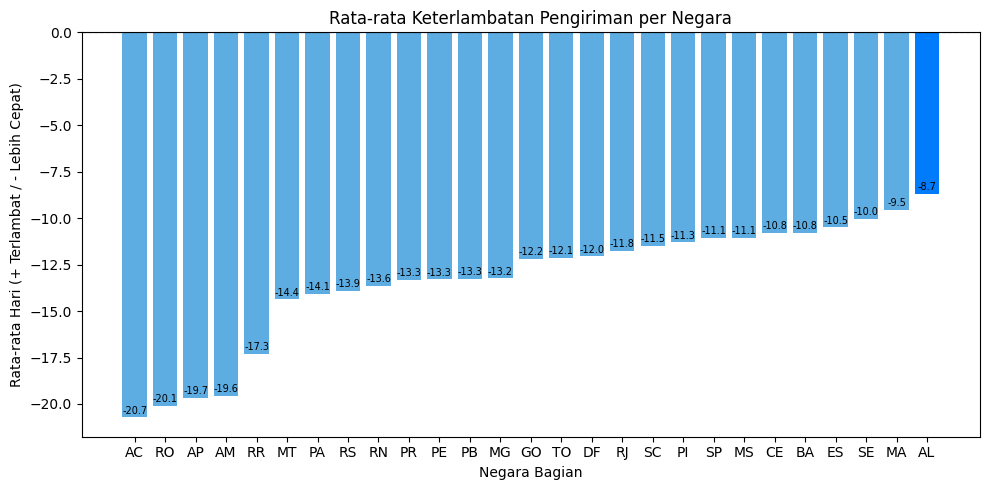

In [395]:
avg_delay = delivery_df.groupby('customer_state')['keterlambatan'].mean().sort_values(ascending=False)

colors = ['#007BFB'] + ['#5DADE2'] * (len(avg_delay)-1)

plt.figure(figsize=(10,5))
bars = plt.bar(avg_delay .index, avg_delay .values, color=colors)

plt.axhline(y=0, color='black', linewidth=0.8, linestyle='--')

plt.title('Rata-rata Keterlambatan Pengiriman per Negara')
plt.xlabel('Negara Bagian')
plt.ylabel('Rata-rata Hari (+ Terlambat / - Lebih Cepat)')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{bar.get_height():.1f}', ha='center', fontsize=7)

plt.tight_layout()
plt.gca().invert_xaxis()

plt.show()

**Insight:**
- Dari hasil visualisasi dapat dilihat top 10 rata rata keterlambatan per negara tertinggi
- Ini menunjukkan ke 10 negara itu masih cukup baik karena yang paling lambat itu negara AL rata ratanya tapi tetap negatif yang mana itu berarti lebih cepat

Note:
- jujur agak bingung ini udah berusaha kali gimana mudah dibaca, karena kan kalo mau buat yang naik ke atas malah jadinya salah karena ini semua minus, jadi disini make sure ttep dari 0, nilainya jelas, ga ada yang ketimpa teksnya. Terus biasanya yang "tertinggi" selalu di paling kanan, tp karena ini versinya ngerendah, jadi agak aneh kalau paling rendah itu paling kanan, tp saya ttp buat kayak gitu karena orang familiar seperti itu dan highlight yang "tertinggi"
- Karena pertanyaan say aawlanay mau tau rata rata keterlambatan seluruh negara maka disini say abuat seluruh negara, mungkin terlihat kecil tp ini karena dari pertanyaan mau liaht awalnya rata rata seliuruh negara


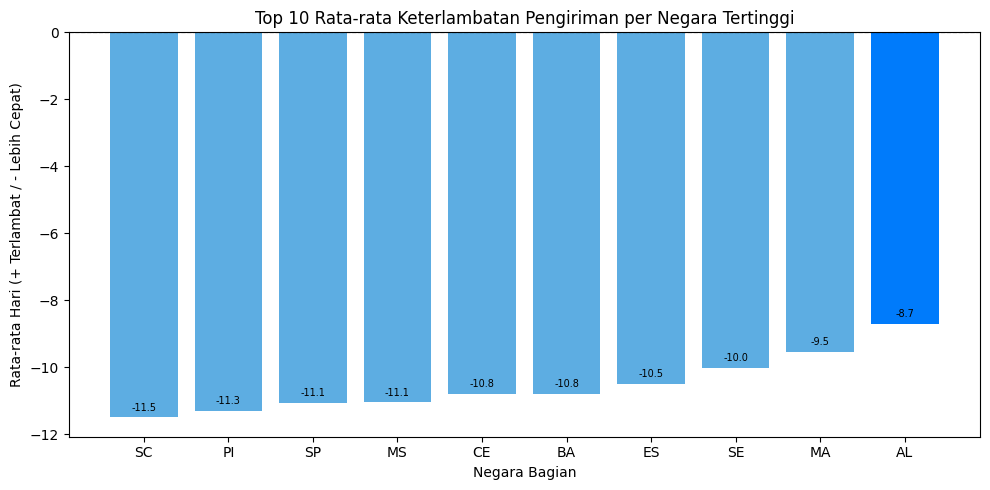

In [396]:
avg_delay = delivery_df.groupby('customer_state')['keterlambatan'].mean().sort_values(ascending=False)

colors = ['#007BFB'] + ['#5DADE2'] * (len(avg_delay)-1)

plt.figure(figsize=(10,5))
bars = plt.bar(avg_delay.head(10) .index, avg_delay.head(10) .values, color=colors)

plt.axhline(y=0, color='black', linewidth=0.8, linestyle='--')

plt.title('Top 10 Rata-rata Keterlambatan Pengiriman per Negara Tertinggi')
plt.xlabel('Negara Bagian')
plt.ylabel('Rata-rata Hari (+ Terlambat / - Lebih Cepat)')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{bar.get_height():.1f}', ha='center', fontsize=7)

plt.tight_layout()
plt.gca().invert_xaxis()

plt.show()

ini jika ingin memuat top 10 yang tertinggi (paling terlambat) dan visualiasi lebih jelas

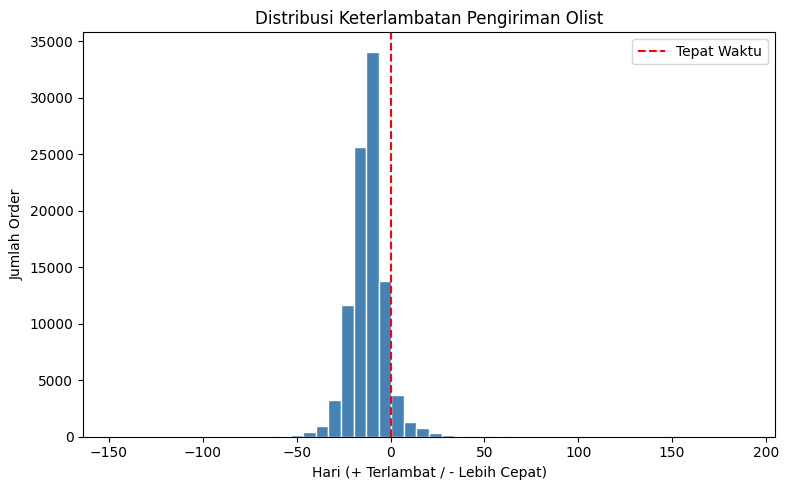

In [397]:
plt.figure(figsize=(8,5))
plt.hist(delivery_df['keterlambatan'].dropna(), bins=50, color='steelblue', edgecolor='white')
plt.axvline(x=0, color='red', linewidth=1.5, linestyle='--', label='Tepat Waktu')
plt.title('Distribusi Keterlambatan Pengiriman Olist')
plt.xlabel('Hari (+ Terlambat / - Lebih Cepat)')
plt.ylabel('Jumlah Order')
plt.legend()
plt.tight_layout()
plt.show()

**Insight:**
- Garis merah pada histogram menunjukkan batas tepat waktu. Distribusi yang condong ke kiri (negatif) berarti mayoritas pengiriman justru lebih cepat dari estimasi yang mana ini hal yang positif.
- Tetapi tetap ada juga yang nilainya positif walaupun sedikit tp menunjukkan masih ada beberapa masalah keterlambatan dan perlu diprioritaskan untuk perbaikan jalur logistik.

### Pertanyaan 2: Kategori produk apa yang paling banyak mendapat review bintang 1-2?

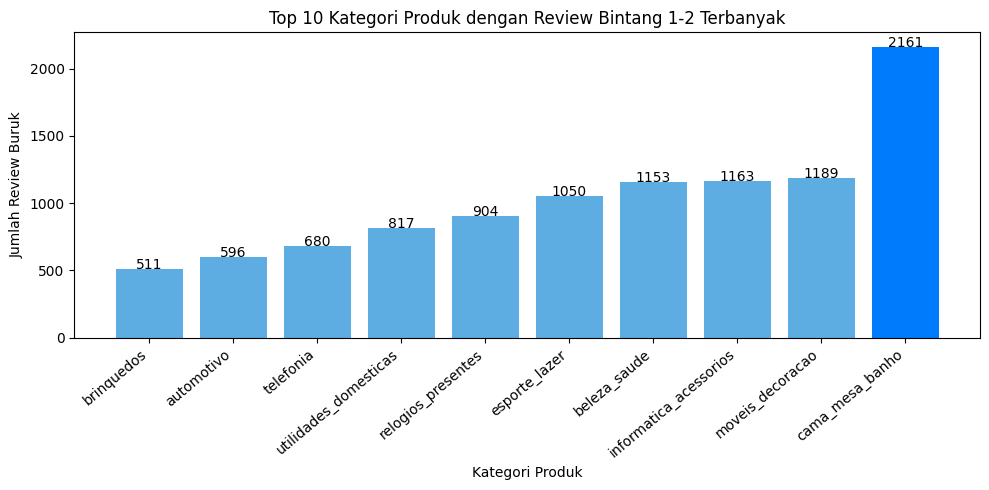

In [398]:
colors = ['#007BFB'] + ['#5DADE2'] * (len(top10_bad_reviews)-1)

plt.figure(figsize=(10,5))
bars = plt.bar(top10_bad_reviews.index, top10_bad_reviews.values, color=colors)

plt.title('Top 10 Kategori Produk dengan Review Bintang 1-2 Terbanyak')
plt.xlabel('Kategori Produk')
plt.ylabel('Jumlah Review Buruk')

plt.xticks(rotation=40, ha='right')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             str(bar.get_height()),
             ha='center',
             fontsize=10)

plt.tight_layout()
plt.gca().invert_xaxis()
plt.show()

**Insight:**
- Dapat dilihat bahwa ini menampilkan top 10 kategori produk  yang mendapatkan review buruk (nilai 1-2) terbanyak
- Hasil menunjukkan bahwa cama_mesa_baho merupakan kategori produk dengan penilaian buruk yang paling banyak sejumlah 2161, tapi belum tentu banyaknya bad review berarti buruk karena bisa saja kategori produk cama_mesa_banho ini yang beli juga banyak, maka disini coba lihat rata ratanya

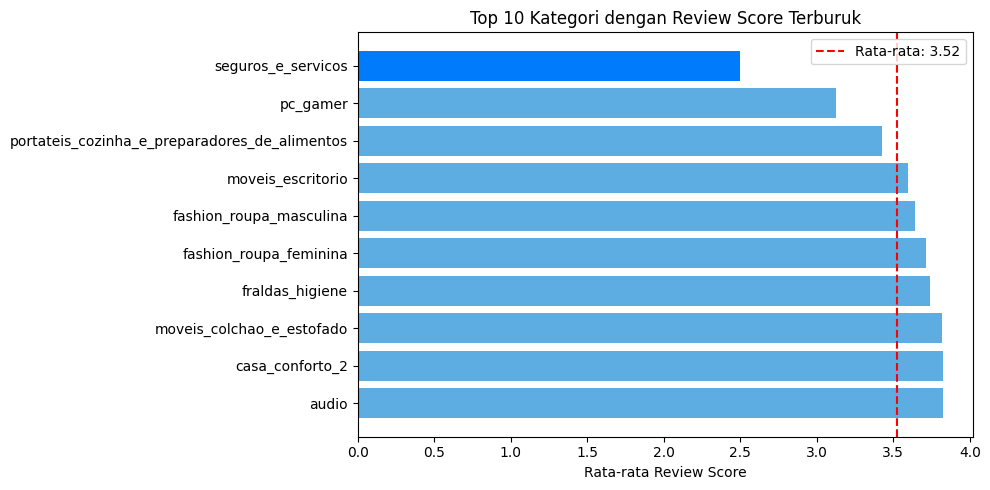

In [399]:
avg_score = review_product.groupby('product_category_name')['review_score'].mean()
worst_categories = avg_score.sort_values().head(10)

plt.figure(figsize=(10,5))
colors = ['#007BFB'] + ['#5DADE2'] * (len(worst_categories)-1)
bars = plt.barh(worst_categories.index, worst_categories.values, color=colors)

plt.axvline(
    x=worst_categories.mean(),
    color='red',
    linestyle='--',
    label=f'Rata-rata: {worst_categories.mean():.2f}'
)

plt.title('Top 10 Kategori dengan Review Score Terburuk')
plt.xlabel('Rata-rata Review Score')
plt.legend()
plt.tight_layout()
plt.gca().invert_yaxis()
plt.show()

**Insight:**
- Dapat dilihat bahwa kategori dengan performa terburuk adalah seguros_e_servicos dengan rata-rata skor sekitar 2.5 jauh lebih rendah dibanding kategori lain. Sementara itu, kategori lain seperti pc_gamer, fashion, dan furniture berada di kisaran skor 3.0-3.8, yang berarti meskipun tidak terlalu buruk, tetap belum mencapai tingkat kepuasan yang optimal.
- Jika dibandingkan dengan garis rata-rata sekitar 3.52, hanya beberapa kategori yang berada di bawah nilai tersebut yang berarti performanya relatif lebih buruk bahkan di antara kategori terburuk.


### Pertanyaan 3: Metode pembayaran apa yang paling sering digunakan pelanggan Olist?


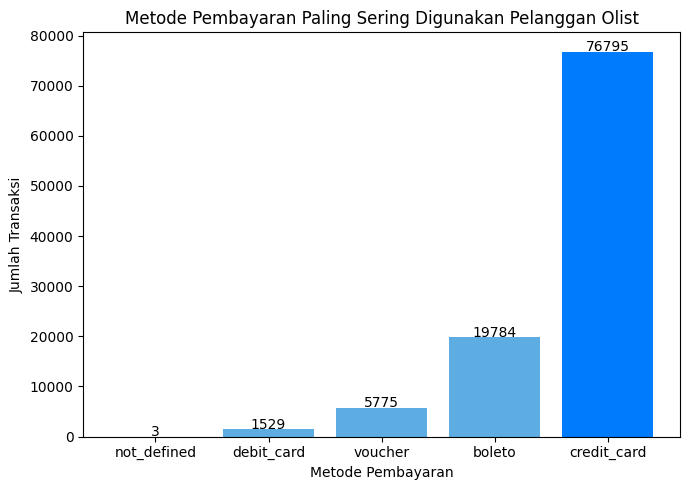

In [400]:
plt.figure(figsize=(7,5))
colors = ['#007BFB'] + ['#5DADE2'] * (len(payment_count)-1)
bars = plt.bar(payment_count.index, payment_count.values, color=colors)
plt.title('Metode Pembayaran Paling Sering Digunakan Pelanggan Olist')
plt.xlabel('Metode Pembayaran')
plt.ylabel('Jumlah Transaksi')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(bar.get_height()), ha='center', fontsize=10)
plt.tight_layout()
plt.gca().invert_xaxis()
plt.show()

**Insight:**
- Dapat dilihat bahwa metode pembayaran yang sering digunakan pelanggan adalah credit_card dengan jumlah transaksi 76795 jauh lebih tinggi dibanding kategori lain.
- DDisini berarti dapat dilihat bahwa rata rata pelanggan lebih memilih menggunakan credit_card untuk bertransaksi


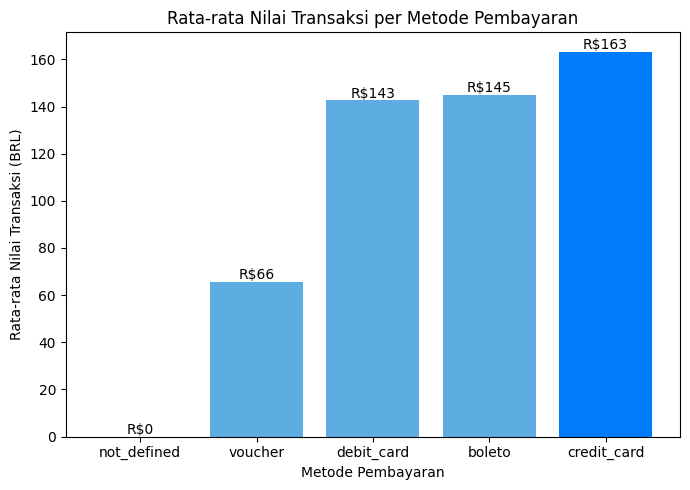

In [401]:
plt.figure(figsize=(7,5))
colors = ['#007BFB'] + ['#5DADE2'] * (len(avg_payment)-1)
bars = plt.bar(avg_payment.index, avg_payment.values, color=colors)
plt.title('Rata-rata Nilai Transaksi per Metode Pembayaran')
plt.xlabel('Metode Pembayaran')
plt.ylabel('Rata-rata Nilai Transaksi (BRL)')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'R${bar.get_height():.0f}', ha='center', fontsize=10)
plt.tight_layout()
plt.gca().invert_xaxis()
plt.show()

**Insight:**
- Kalau sebelumnya hanya dilihat dari jumlah transaksi, ini dilihar dari rata rata nilai transaksi, dapat dilihat bahwa credit_card tetap tertinggi
- Ini menunjukkan bahwa pelanggan cenderung melakukan pembelian dengan nilai lebih besar saat menggunakan credit_card

## Analisis Lanjutan (Opsional)

untuk analisis lanjutan saya akan buat analsisnya terlebih dahulu dan visualisasikannya per pertanyaan

### Pertanyaan 4 dan 5: Siapa saja pelanggan paling bernilai di Olist berdasarkan seberapa sering dan seberapa besar mereka bertransaksi? dan Berapa persentase pelanggan Olist yang sudah lama tidak melakukan transaksi kembali?

In [402]:
rfm_df = orders_df[orders_df['order_status'] == 'delivered'].merge(
    payments_df.groupby('order_id')['payment_value'].sum().reset_index(),
    on='order_id'
).merge(
    customers_df[['customer_id', 'customer_unique_id']],
    on='customer_id'
)

**Insight:**
- Kode ini untuk mengambil hanya order yang sudah delivered, lalu menggabungkan dengan total nilai pembayaran per order dan data identitas pelanggan unik.
- Jadi kode ini nanti akan menghasilkan tabel yang berisi setiap order beserta nilai transaksinya dan siapa pelanggan yang melakukan order tersebut



In [403]:
snapshot_date = rfm_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

In [404]:
rfm = rfm_df.groupby('customer_unique_id').agg(
    Recency=('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    Frequency=('order_id', 'count'),
    Monetary=('payment_value', 'sum')
).reset_index()

rfm.describe()

,Recency,Frequency,Monetary
count,93335.000000,93335.000000,93335.000000
mean,237.898752,1.033417,165.199917
std,152.545822,0.209099,226.335837
min,1.000000,1.000000,9.590000
25%,114.000000,1.000000,63.050000
50%,219.000000,1.000000,107.780000
75%,346.000000,1.000000,182.545000
max,695.000000,15.000000,13664.080000


**Insight:**
- Kode ini untuk menghitng 3 nilai utama RFM untuk setiap pelanggan unik yang menghasilkan tabel RFM
Recency: berapa hari sejak terakhir transaksi
Frequency: berapa kali total transaksi
Monetary: berapa total nilai belanja
- Disini dapat dilihat dari sisi Recency dan Frequency, terlihat bahwa mayoritas customer sudah lama tidak melakukan pembelian (rata-rata ~237 hari) dan hampir semuanya hanya membeli 1 kali saja (median = 1). Ini menunjukkan bahwa banyak customer bersifat one-time buyer dan tingkat retensi masih rendah, sehingga bisnis perlu fokus pada strategi untuk meningkatkan pembelian ulang
- Dari sisi Monetary, nilai transaksi cukup bervariasi dengan rata-rata sekitar 165 dan adanya nilai maksimum yang sangat tinggi jadi meskipun sebagian besar customer berbelanja dalam jumlah kecil-menengah, terdapat segmen kecil customer dengan nilai transaksi besar yang berpotensi menjadi high-value customer

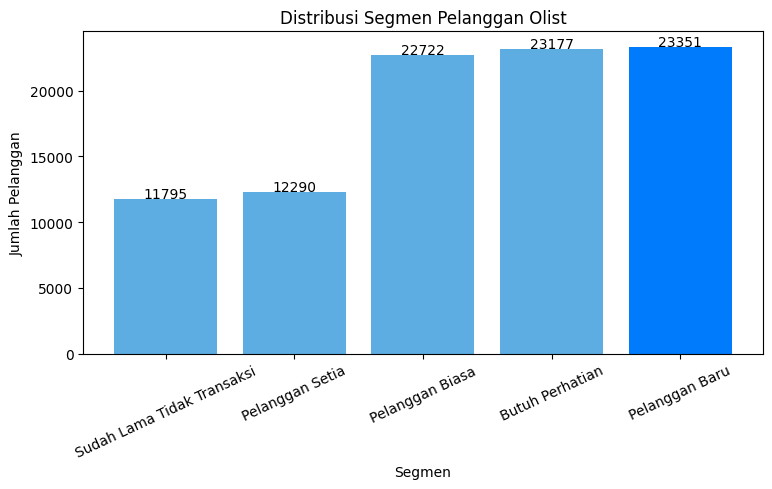

In [405]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

def segment(row):
    r, f, m = int(row['R_score']), int(row['F_score']), int(row['M_score'])
    if r >= 3 and f >= 3 and m >= 3:
        return 'Pelanggan Setia'
    elif r >= 3 and f <= 2:
        return 'Pelanggan Baru'
    elif r <= 2 and f >= 3:
        return 'Butuh Perhatian'
    elif r == 1:
        return 'Sudah Lama Tidak Transaksi'
    else:
        return 'Pelanggan Biasa'

rfm['Segment'] = rfm.apply(segment, axis=1)

plt.figure(figsize=(8,5))
segment_count = rfm['Segment'].value_counts()
colors = ['#007BFB'] + ['#5DADE2'] * (len(segment_count)-1)
bars = plt.bar(segment_count.index, segment_count.values, color=colors)
plt.title('Distribusi Segmen Pelanggan Olist')
plt.xlabel('Segmen')
plt.ylabel('Jumlah Pelanggan')
plt.xticks(rotation=25)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(bar.get_height()), ha='center', fontsize=10)
plt.tight_layout()
plt.gca().invert_xaxis()
plt.show()

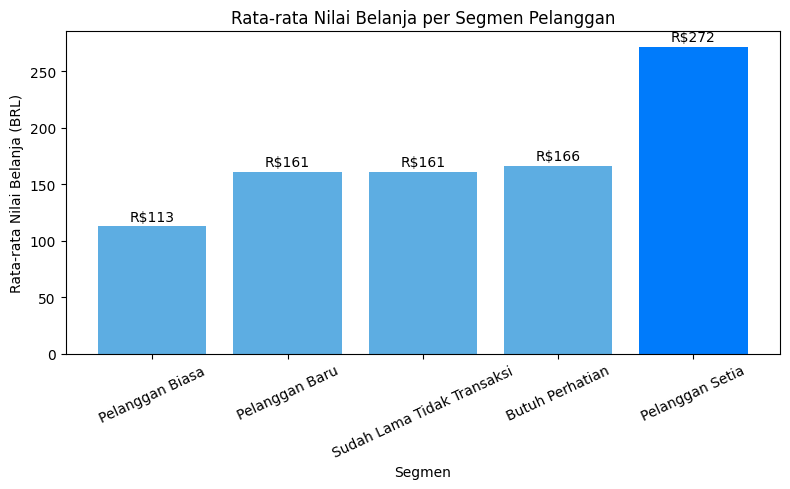

In [406]:
plt.figure(figsize=(8,5))
monetary_segment = rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending=False)
colors = ['#007BFB'] + ['#5DADE2'] * (len(monetary_segment)-1)
bars = plt.bar(monetary_segment.index, monetary_segment.values, color=colors)
plt.title('Rata-rata Nilai Belanja per Segmen Pelanggan')
plt.xlabel('Segmen')
plt.ylabel('Rata-rata Nilai Belanja (BRL)')
plt.xticks(rotation=25)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'R${bar.get_height():.0f}', ha='center', fontsize=10)
plt.tight_layout()
plt.gca().invert_xaxis()
plt.show()

**Insight:**
- Dari visualisasi ini dapat dilihat untnuk segmen pelanggan mana yang paling dominan di Olist
- Segmen Pelanggan Setia adalah yang paling bernilai karena meskipun jumlah Pelanggan Setia (12.290 orang) lebih sedikit dibandingkan Pelanggan Baru (23.351 orang) tetapi kontribusi finansial mereka per individu sangat dominan
- Segmen Sudah Lama Tidak Transaksi perlu mendapat perhatian khusus karena berisiko tidak kembali lagi karena sudah lama tidak bertransaksi dan rata rata nilai belanjanya juga rendah lebih rendah dari pelanggan yang butuh perhatian

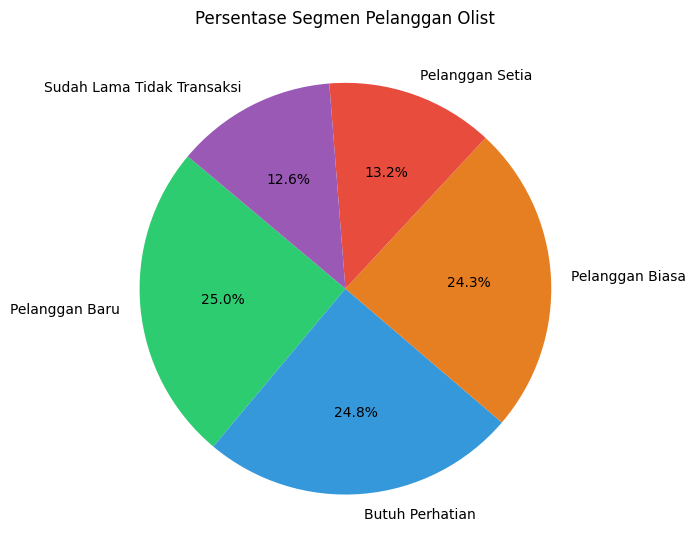

In [407]:
segment_pct = rfm['Segment'].value_counts(normalize=True) * 100

plt.figure(figsize=(7,7))
colors = ['#2ecc71','#3498db','#e67e22','#e74c3c','#9b59b6']
plt.pie(segment_pct.values, labels=segment_pct.index, autopct='%1.1f%%',
        colors=colors, startangle=140)
plt.title('Persentase Segmen Pelanggan Olist')
plt.tight_layout()
plt.show()

In [408]:
churn_risk = rfm[rfm['Segment'] == 'Sudah Lama Tidak Transaksi']
print(f"Jumlah pelanggan yang sudah lama tidak transaksi: {len(churn_risk)}")
print(f"Persentase dari total pelanggan: {round(len(churn_risk)/len(rfm)*100, 2)}%")
print(f"Rata-rata hari sejak transaksi terakhir: {churn_risk['Recency'].mean().round(0)} hari")

Jumlah pelanggan yang sudah lama tidak transaksi: 11795
Persentase dari total pelanggan: 12.64%
Rata-rata hari sejak transaksi terakhir: 451.0 hari


**Insight:**
- Pie chart di atas menunjukkan proporsi setiap segmen pelanggan secara keseluruhan
- Persentase segmen Sudah Lama Tidak Transaksi berada di 12,64% dari toal pelanggan, ini termasuk cukup banyak walaupun tidak besar maka perlu adanya strategi untuk menarik pelanggan tersebut kembali berbelanja



### Pertanyaan 6: Di kota atau negara bagian mana pelanggan paling bernilai di Olist paling banyak tersebar?

In [409]:
rfm_geo = rfm.merge(
    customers_df[['customer_unique_id', 'customer_city', 'customer_state']],
    on='customer_unique_id'
)
rfm_geo.head()

,customer_unique_id,Recency,Frequency,Monetary,R_score,F_score,M_score,Segment,customer_city,customer_state
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,3,Pelanggan Baru,cajamar,SP
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,3,1,1,Pelanggan Baru,osasco,SP
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,Sudah Lama Tidak Transaksi,sao jose,SC
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,Pelanggan Biasa,belem,PA
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,Pelanggan Biasa,sorocaba,SP


**Insight:**
- Kode ini untuk menggabungkan data RFM dengan lokasi pelanggan agar bisa melihat sebaran pelanggan bernilai tinggi per wilayahnya
- Negara bagian dengan pelanggan paling bernilai di Olist paling banyak adalah SP. Hal ini terlihat dari hasil penggabungan data RFM dengan lokasi, di mana banyak customer dengan nilai Monetary yang cukup tinggi serta aktivitas pembelian yang relatif lebih baik berasal dari kota-kota di SP seperti cajamar, osasco, dan sorocaba

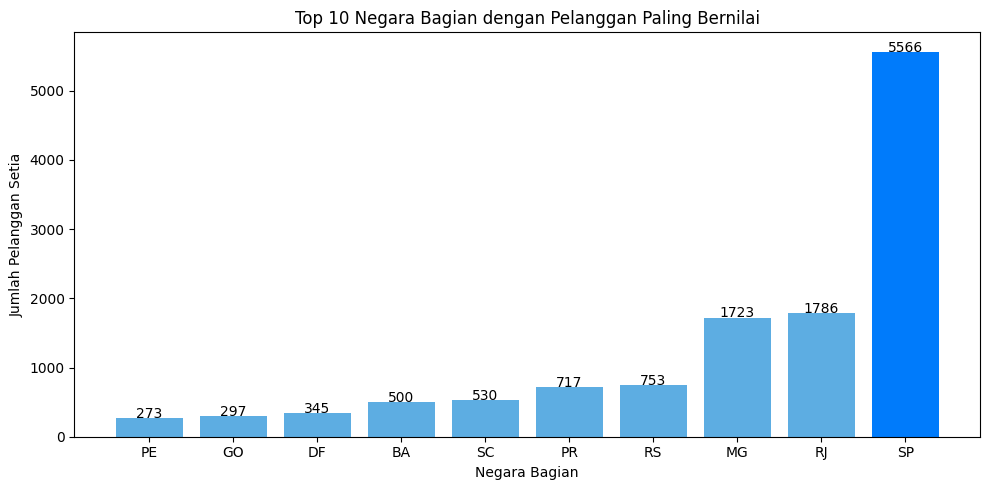

In [410]:
rfm_geo = rfm.merge(
    customers_df[['customer_unique_id', 'customer_city', 'customer_state']],
    on='customer_unique_id'
)

top_customers = rfm_geo[rfm_geo['Segment'] == 'Pelanggan Setia']

plt.figure(figsize=(10,5))
state_count = top_customers['customer_state'].value_counts().head(10)
colors = ['#007BFB'] + ['#5DADE2'] * (len(state_count)-1)
bars = plt.bar(state_count.index, state_count.values, color=colors)
plt.title('Top 10 Negara Bagian dengan Pelanggan Paling Bernilai')
plt.xlabel('Negara Bagian')
plt.ylabel('Jumlah Pelanggan Setia')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(bar.get_height()), ha='center', fontsize=10)
plt.tight_layout()
plt.gca().invert_xaxis()
plt.show()

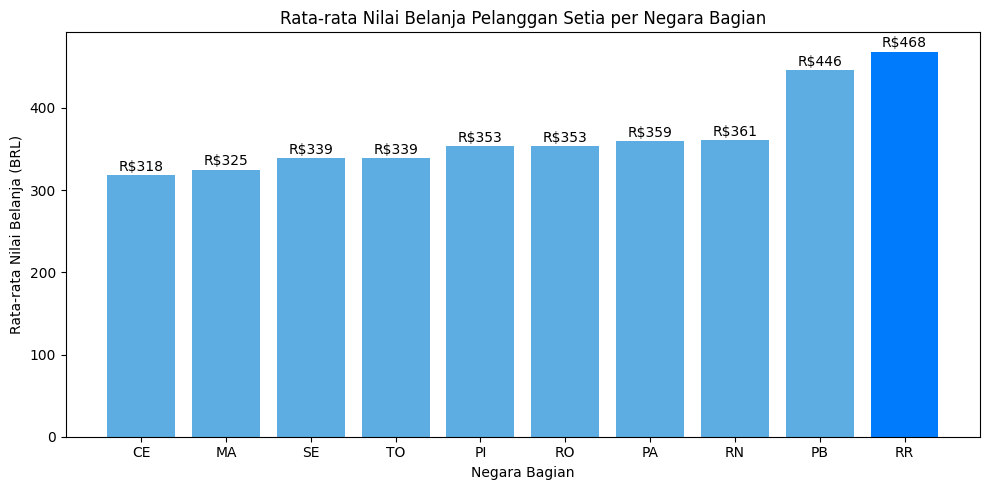

In [411]:
plt.figure(figsize=(10,5))
monetary_state = top_customers.groupby('customer_state')['Monetary'].mean().sort_values(ascending=False).head(10)
colors = ['#007BFB'] + ['#5DADE2'] * (len(monetary_state)-1)
bars = plt.bar(monetary_state.index, monetary_state.values, color=colors)
plt.title('Rata-rata Nilai Belanja Pelanggan Setia per Negara Bagian')
plt.xlabel('Negara Bagian')
plt.ylabel('Rata-rata Nilai Belanja (BRL)')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'R${bar.get_height():.0f}', ha='center', fontsize=10)
plt.tight_layout()
plt.gca().invert_xaxis()
plt.show()

**Insight:**
- Pada visualisasi ini menunjukkan bahwa lokasi pelanggan paling bernilai berada secara geografis
- Negara bagian yang muncul di posisi teratas ialah SP dengan jumlah pelanggan setia terbanyak, tetapi untuk rata rata nilai belanja, negara RR yang unggul. Dari hasil yang kita tahu dapat bisa dijadikan prioritas untuk kampanye marketing atau pengirimanlebih cepat dan lainnya

## Conclusion

- Conclution pertanyaan 1: Rata-rata keterlambatan pengiriman di 10 negara bagian Brazil menunjukkan nilai negatif yang berarti pengiriman umumnya tiba lebih cepat dari waktu estimasi. Negara bagian seperti SC, PI, dan SP memiliki rata-rata waktu pengiriman paling cepat (sekitar 11 hari lebih cepat dari estimasi). Meskipun AL memiliki rata-rata paling tinggi di antara 10 tersebut (sekitar -8.7 hari), nilainya masih negatif sehingga tetap tergolong baik. Secara keseluruhan, performa logistik sudah cukup baik.

- Conclution pertanyaan 2: Kategori cama_mesa_banho memiliki jumlah review buruk (bintang 1-2) paling banyak walaupun belum tentu menunjukkan kualitasnya paling buruk karena kemungkinan jumlah pembelinya juga sangat besar. Oleh karena itu perlu melihat rata-rata skor untuk menilai kualitas secara lebih adil. Dari rata-rata skor, kategori seguros_e_servicos memiliki performa terburuk karena nilai rata-ratanya paling rendah (sekitar 2.5), jauh di bawah rata-rata keseluruhan (sekitar 3.52). Ini menunjukkan kategori tersebut memiliki tingkat kepuasan pelanggan yang paling rendah dan perlu menjadi prioritas perbaikan.

- Conclution pertangaan 3: Metode pembayaran yang paling sering digunakan pelanggan Olist adalah credit card, baik dari jumlah transaksi maupun dari rata-rata nilai transaksinya. Hal ini menunjukkan bahwa pelanggan lebih nyaman menggunakan kartu kredit untuk bertransaksi. Selain itu, rata-rata nilai transaksi dengan credit card juga paling tinggi yang berarti pelanggan cenderung melakukan pembelian dengan nilai lebih besar saat menggunakan metode ini.

- Conclution pertanyaan 4: Pelanggan paling bernilai di Olist adalah pelanggan setia karena meskipun jumlahnya tidak sebanyak pelanggan baru, mereka lebih sering bertransaksi dan memberikan kontribusi nilai belanja yang lebih besar per pelanggan.

- Conclution pertanyaan 5: Sekitar 12,64% pelanggan Olist termasuk dalam kategori sudah lama tidak melakukan transaksi kembali. Meskipun persentasenya tidak terlalu besar, jumlah ini tetap penting untuk diperhatikan karena menunjukkan adanya pelanggan yang berpotensi tidak kembali berbelanja.

- Conclution pertanyaan 6: Pelanggan paling bernilai di Olist paling banyak tersebar di negara bagian SP hal ini menunjukkan bahwa wilayah SP merupakan kontributor utama pelanggan dengan frekuensi transaksi dan total belanja yang tinggi. Namun, jika dilihat dari rata-rata nilai belanja per pelanggan, negara bagian RR justru memiliki nilai rata-rata yang lebih tinggi. Ini berarti meskipun jumlah pelanggan bernilai tinggi di SP lebih banyak, pelanggan di RR cenderung memiliki nilai transaksi yang lebih besar per orang.

In [412]:
sellers_df.to_csv("sellers.csv", index=False)
products_df.to_csv("products.csv", index=False)
reviews_df.to_csv("reviews.csv", index=False)
orders_df.to_csv("orders.csv", index=False)
payments_df.to_csv("payments.csv", index=False)
items_df.to_csv("items.csv", index=False)
geolocation_df.to_csv("geolocation.csv", index=False)
customers_df.to_csv("customers.csv", index=False)